# Trabajo Final - Preparacion inicial del dataset de volatilidad del SPY

## Tema
**Analisis y pronostico de la volatilidad del S&P 500 mediante modelos de series de tiempo**

## Objetivo de este notebook
Construir un pipeline reproducible para descargar, limpiar, preparar y explorar datos diarios del ETF `SPY` entre `2010-01-01` y `2025-12-31`, dejando un dataset listo para etapas posteriores de modelado.

## Alcance
- Descargar datos diarios desde `yfinance`.
- Inspeccionar estructura, calidad y cobertura temporal.
- Limpiar la serie sin alterar la logica del calendario bursatil.
- Construir variables de retorno y volatilidad movil.
- Realizar una exploracion descriptiva inicial.
- Separar el dataset en conjuntos temporales de entrenamiento, validacion y prueba.
- Guardar salidas reutilizables para notebooks posteriores.

## Lo que no se hace en esta etapa
Todavia no se entrenan modelos como ARIMA, GARCH, Prophet o LSTM. El foco es preparar una base consistente, reproducible y metodologicamente correcta.

## 1. Introduccion

Se utiliza el ETF `SPY` como proxy del indice S&P 500 porque replica de manera cercana el comportamiento agregado de las 500 empresas de mayor capitalizacion del mercado estadounidense y cuenta con datos historicos diarios facilmente accesibles.

En series financieras no corresponde completar fines de semana ni feriados, ya que en esos dias no hubo negociacion. Rellenar observaciones inexistentes introduciria senales artificiales y distorsionaria retornos, autocorrelaciones y medidas de volatilidad.

Para estudiar dinamica financiera es habitual trabajar con retornos en lugar de precios. En particular, los retornos logaritmicos resultan utiles porque representan cambios relativos, suelen ser mas estables para el analisis y son aditivos en el tiempo.

Como primera aproximacion a la volatilidad, se utilizara el desvio estandar movil de los retornos logaritmicos. Esta medida no reemplaza modelos formales de volatilidad, pero permite detectar periodos de mayor o menor variabilidad y explorar si existe persistencia temporal.

Tambien se explicita desde esta etapa que cualquier feature predictora debe construirse usando solo informacion disponible hasta el instante actual. Esto evita `data leakage`, un problema central en series de tiempo. Por la misma razon, la division entre train, validation y test debe respetar estrictamente el orden cronologico.

In [3]:
# Configuracion general e importacion de librerias.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

TICKER = "SPY"
START_DATE = "2010-01-01"
END_DATE = "2025-12-31"

VOL_WINDOWS = [5, 21, 63]

TRAIN_END = "2020-12-31"
VALID_END = "2023-12-31"

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio base: {BASE_DIR}")
print(f"Activo: {TICKER}")
print(f"Periodo solicitado: {START_DATE} a {END_DATE}")

Directorio base: /home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal
Activo: SPY
Periodo solicitado: 2010-01-01 a 2025-12-31


## 2. Descarga de datos

La descarga se realiza desde `yfinance` para frecuencia diaria. Se conserva una copia cruda antes de cualquier transformacion, de modo que el proceso sea auditable y pueda repetirse en el futuro.

In [4]:
def descargar_spy(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Descarga datos diarios desde yfinance y devuelve un DataFrame con indice de fechas."""
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=False,
        progress=False,
    )

    if df.empty:
        raise ValueError("La descarga devolvio un DataFrame vacio. Revisar conectividad o parametros.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"
    return df


spy_raw = descargar_spy(TICKER, START_DATE, END_DATE)
raw_path = RAW_DIR / f"{TICKER.lower()}_raw.csv"
spy_raw.to_csv(raw_path)

print(f"Filas descargadas: {len(spy_raw):,}")
print(f"Primera fecha disponible: {spy_raw.index.min().date()}")
print(f"Ultima fecha disponible: {spy_raw.index.max().date()}")
print(f"Copia cruda guardada en: {raw_path}")
spy_raw.head()

Filas descargadas: 4,023
Primera fecha disponible: 2010-01-04
Ultima fecha disponible: 2025-12-30
Copia cruda guardada en: /home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal/data/raw/spy_raw.csv


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,84.796379,113.330002,113.389999,111.510002,112.370003,118944600
2010-01-05,85.020828,113.629997,113.680000,112.849998,113.260002,111579900
2010-01-06,85.080688,113.709999,113.989998,113.430000,113.519997,116074400
2010-01-07,85.439865,114.190002,114.330002,113.180000,113.500000,131091100
2010-01-08,85.724159,114.570000,114.620003,113.660004,113.889999,126402800


## 3. Inspeccion inicial

Antes de limpiar o transformar la serie conviene revisar su forma, sus tipos de datos y posibles problemas basicos como nulos, duplicados o inconsistencias de indice.

In [5]:
print("Dimensiones:", spy_raw.shape)
print("\nTipos de datos:")
print(spy_raw.dtypes)

print("\nValores nulos por columna:")
print(spy_raw.isna().sum())

print("\nDuplicados de fecha:", spy_raw.index.duplicated().sum())
print("Indice monotonicamente creciente:", spy_raw.index.is_monotonic_increasing)

display(spy_raw.head())
display(spy_raw.tail())
display(spy_raw.describe().T)

Dimensiones: (4023, 6)

Tipos de datos:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Valores nulos por columna:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicados de fecha: 0
Indice monotonicamente creciente: True


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,84.796379,113.330002,113.389999,111.510002,112.370003,118944600
2010-01-05,85.020828,113.629997,113.680000,112.849998,113.260002,111579900
2010-01-06,85.080688,113.709999,113.989998,113.430000,113.519997,116074400
2010-01-07,85.439865,114.190002,114.330002,113.180000,113.500000,131091100
2010-01-08,85.724159,114.570000,114.620003,113.660004,113.889999,126402800


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-23,686.086304,687.960022,688.200012,683.869995,683.919983,64840000
2025-12-24,688.499695,690.380005,690.830017,687.799988,687.950012,39445600
2025-12-26,688.429871,690.309998,691.659973,689.270020,690.640015,41613300
2025-12-29,685.976562,687.849976,689.200012,686.070007,687.539978,62559500
2025-12-30,685.138916,687.010010,688.559998,686.580017,687.450012,47160700


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Adj Close,"4,023.000000",267.967762,155.480151,77.148857,146.221687,227.698746,386.302002,688.499695
Close,"4,023.000000",293.986716,148.404073,102.199997,180.970001,258.089996,406.755005,690.380005
High,"4,023.000000",295.506217,149.129892,103.419998,181.544998,259.160004,408.574997,691.659973
Low,"4,023.000000",292.215031,147.544146,101.129997,180.389999,256.410004,404.029999,689.270020
Open,"4,023.000000",293.932908,148.385242,103.110001,180.854996,257.730011,406.569992,690.640015
Volume,"4,023.000000","109,368,830.077057","67,971,253.287828","20,270,000.000000","65,235,350.000000","89,433,100.000000","132,885,750.000000","717,828,700.000000"


## 4. Limpieza y validacion

La limpieza prioriza conservar la estructura real de la serie financiera. No se agregan dias sin negociacion. En cambio, se valida que el indice este ordenado, que no existan duplicados y que los precios mantengan coherencia interna.

Se conserva `Adj Close` si existe, ya que puede ser una referencia mas adecuada para retornos historicos al considerar ajustes por dividendos y eventos corporativos.

In [6]:
def limpiar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """Limpia y valida la serie sin imputar dias no observados."""
    clean = df.copy()
    clean = clean.sort_index()
    clean = clean.loc[~clean.index.duplicated(keep="first")]

    # Renombrado consistente para facilitar trabajo posterior.
    clean.columns = [col.strip().replace(" ", "_") for col in clean.columns]

    columnas_precio = [col for col in ["Open", "High", "Low", "Close", "Adj_Close"] if col in clean.columns]
    for col in columnas_precio:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

    if "Volume" in clean.columns:
        clean["Volume"] = pd.to_numeric(clean["Volume"], errors="coerce")

    # Verificaciones minimas de coherencia de OHLC.
    if {"High", "Low"}.issubset(clean.columns):
        inconsistent_range = clean[clean["High"] < clean["Low"]]
        if not inconsistent_range.empty:
            raise ValueError("Se detectaron filas con High < Low.")

    if {"Open", "High", "Low"}.issubset(clean.columns):
        inconsistent_open = clean[(clean["Open"] > clean["High"]) | (clean["Open"] < clean["Low"])]
        if not inconsistent_open.empty:
            print(f"Advertencia: {len(inconsistent_open)} filas con Open fuera del rango [Low, High].")

    if {"Close", "High", "Low"}.issubset(clean.columns):
        inconsistent_close = clean[(clean["Close"] > clean["High"]) | (clean["Close"] < clean["Low"])]
        if not inconsistent_close.empty:
            print(f"Advertencia: {len(inconsistent_close)} filas con Close fuera del rango [Low, High].")

    clean = clean.dropna(subset=[col for col in ["Open", "High", "Low", "Close"] if col in clean.columns])
    return clean


spy_clean = limpiar_datos(spy_raw)

print("Filas luego de limpieza:", len(spy_clean))
print("Rango temporal limpio:", spy_clean.index.min().date(), "->", spy_clean.index.max().date())
print("Nulos remanentes:")
print(spy_clean.isna().sum())

spy_clean.head()

Filas luego de limpieza: 4023
Rango temporal limpio: 2010-01-04 -> 2025-12-30
Nulos remanentes:
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


,Adj_Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,84.796379,113.330002,113.389999,111.510002,112.370003,118944600
2010-01-05,85.020828,113.629997,113.680000,112.849998,113.260002,111579900
2010-01-06,85.080688,113.709999,113.989998,113.430000,113.519997,116074400
2010-01-07,85.439865,114.190002,114.330002,113.180000,113.500000,131091100
2010-01-08,85.724159,114.570000,114.620003,113.660004,113.889999,126402800


## 5. Feature engineering

Se construyen variables basicas para el estudio de la volatilidad:
- retorno simple diario,
- retorno logaritmico diario,
- retorno absoluto,
- volatilidad movil calculada como desvio estandar rolling de retornos logaritmicos,
- lags de variables relevantes.

Todas estas features se calculan usando informacion historica. Esto es importante para evitar `data leakage` cuando luego se definan targets y modelos.

In [7]:
def construir_features(df: pd.DataFrame, vol_windows: list[int]) -> pd.DataFrame:
    """Construye retornos, volatilidad movil y lags utiles para modelado posterior."""
    feat = df.copy()

    price_col = "Adj_Close" if "Adj_Close" in feat.columns else "Close"
    feat["price_base"] = feat[price_col]

    feat["return_simple"] = feat["price_base"].pct_change()
    feat["return_log"] = np.log(feat["price_base"] / feat["price_base"].shift(1))
    feat["return_abs"] = feat["return_log"].abs()

    for window in vol_windows:
        feat[f"volatility_{window}d"] = feat["return_log"].rolling(window=window).std()
        feat[f"mean_abs_return_{window}d"] = feat["return_abs"].rolling(window=window).mean()

    for lag in [1, 2, 5, 10]:
        feat[f"return_log_lag_{lag}"] = feat["return_log"].shift(lag)

    feat["year"] = feat.index.year
    feat["month"] = feat.index.month
    feat["weekday"] = feat.index.weekday

    return feat


spy_feat = construir_features(spy_clean, VOL_WINDOWS)

print("Columnas disponibles:")
print(spy_feat.columns.tolist())

display(spy_feat[[col for col in spy_feat.columns if col.startswith("return") or col.startswith("volatility")]].head(10))

Columnas disponibles:
['Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'price_base', 'return_simple', 'return_log', 'return_abs', 'volatility_5d', 'mean_abs_return_5d', 'volatility_21d', 'mean_abs_return_21d', 'volatility_63d', 'mean_abs_return_63d', 'return_log_lag_1', 'return_log_lag_2', 'return_log_lag_5', 'return_log_lag_10', 'year', 'month', 'weekday']


,return_simple,return_log,return_abs,volatility_5d,volatility_21d,volatility_63d,return_log_lag_1,return_log_lag_2,return_log_lag_5,return_log_lag_10
Date,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,0.002647,0.002643,0.002643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,0.000704,0.000704,0.000704,NaN,NaN,NaN,0.002643,NaN,NaN,NaN
2010-01-07,0.004222,0.004213,0.004213,NaN,NaN,NaN,0.000704,0.002643,NaN,NaN
2010-01-08,0.003327,0.003322,0.003322,NaN,NaN,NaN,0.004213,0.000704,NaN,NaN
2010-01-11,0.001397,0.001396,0.001396,0.001420,NaN,NaN,0.003322,0.004213,NaN,NaN
2010-01-12,-0.009326,-0.009370,0.009370,0.005454,NaN,NaN,0.001396,0.003322,0.002643,NaN
2010-01-13,0.008446,0.008410,0.008410,0.006644,NaN,NaN,-0.009370,0.001396,0.000704,NaN
2010-01-14,0.002705,0.002701,0.002701,0.006528,NaN,NaN,0.008410,-0.009370,0.004213,NaN


## 6. Analisis exploratorio

En esta etapa interesa observar si la serie presenta rasgos compatibles con el estudio posterior de volatilidad, por ejemplo:
- cambios de nivel en precios,
- concentracion de retornos extremos,
- persistencia visual en periodos de alta variabilidad,
- distribuciones alejadas de la normalidad.

No se extraen conclusiones definitivas de modelado, pero si se genera evidencia descriptiva para justificar los siguientes pasos del trabajo.

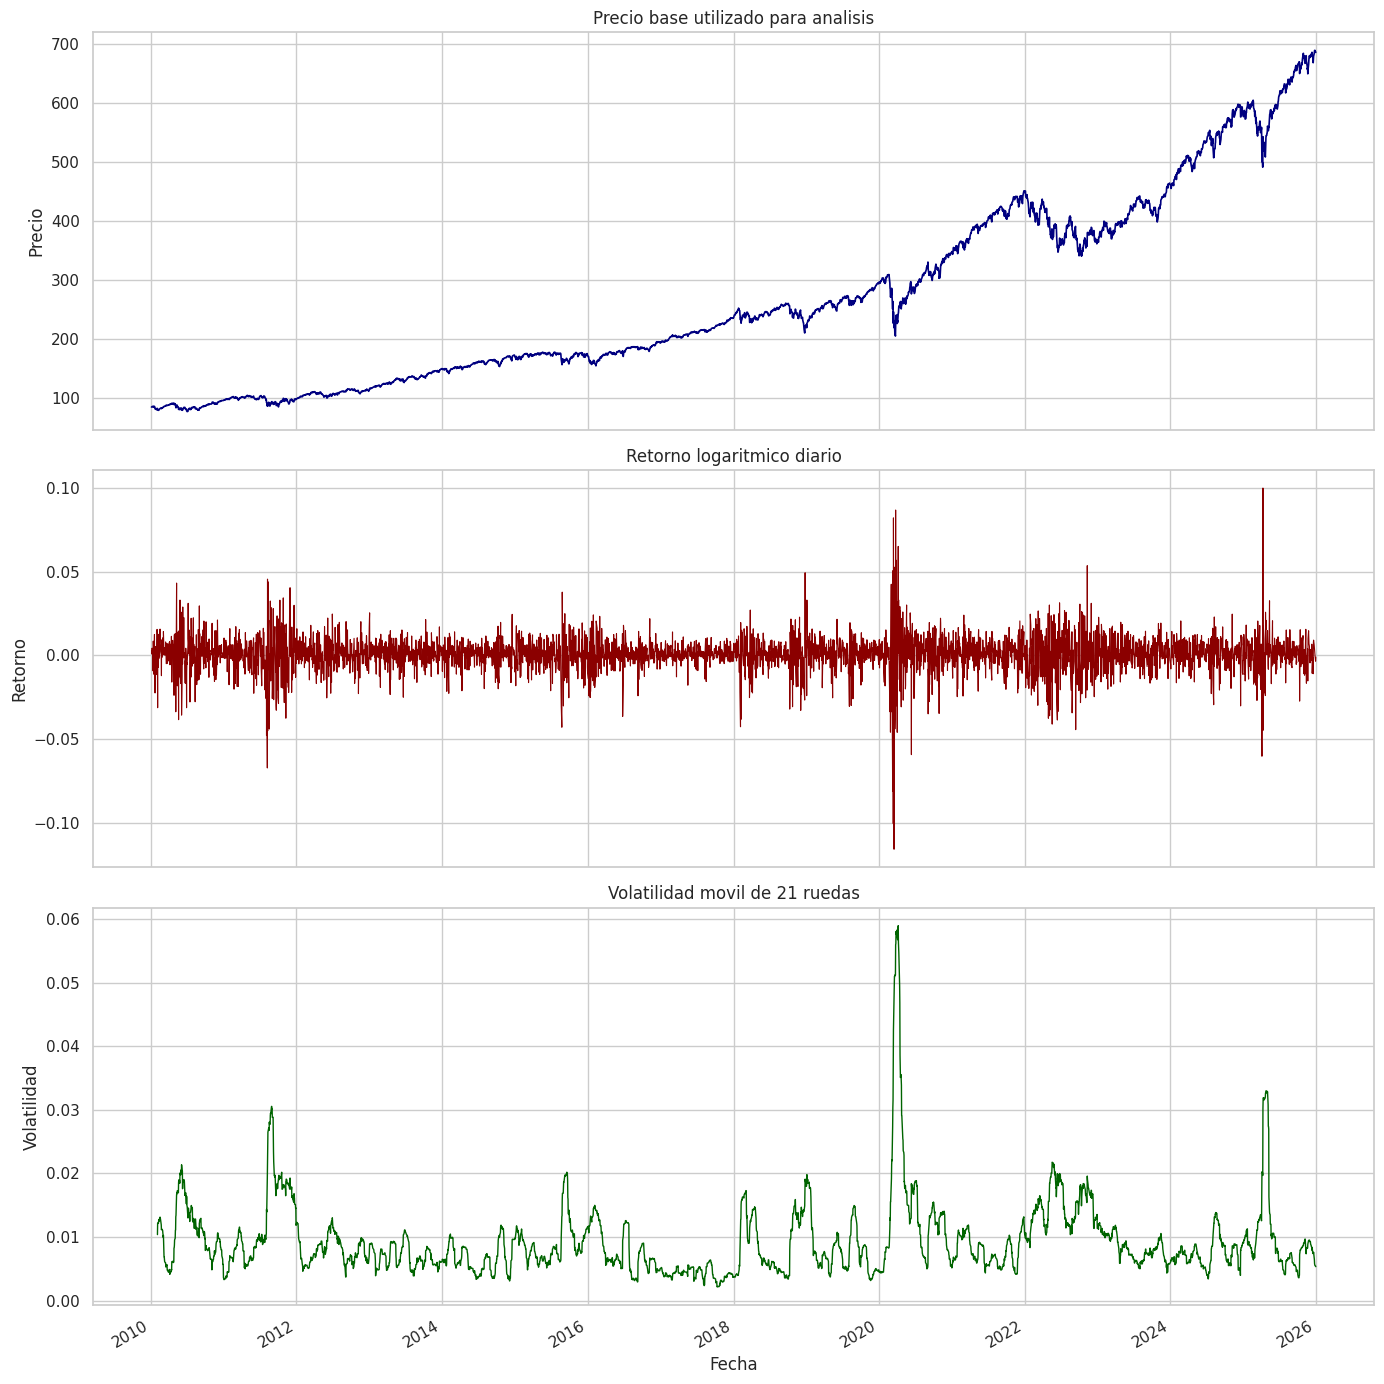

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

spy_feat["price_base"].plot(ax=axes[0], color="navy", linewidth=1.2)
axes[0].set_title("Precio base utilizado para analisis")
axes[0].set_ylabel("Precio")

spy_feat["return_log"].plot(ax=axes[1], color="darkred", linewidth=0.8)
axes[1].set_title("Retorno logaritmico diario")
axes[1].set_ylabel("Retorno")

spy_feat["volatility_21d"].plot(ax=axes[2], color="darkgreen", linewidth=1.0)
axes[2].set_title("Volatilidad movil de 21 ruedas")
axes[2].set_ylabel("Volatilidad")
axes[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

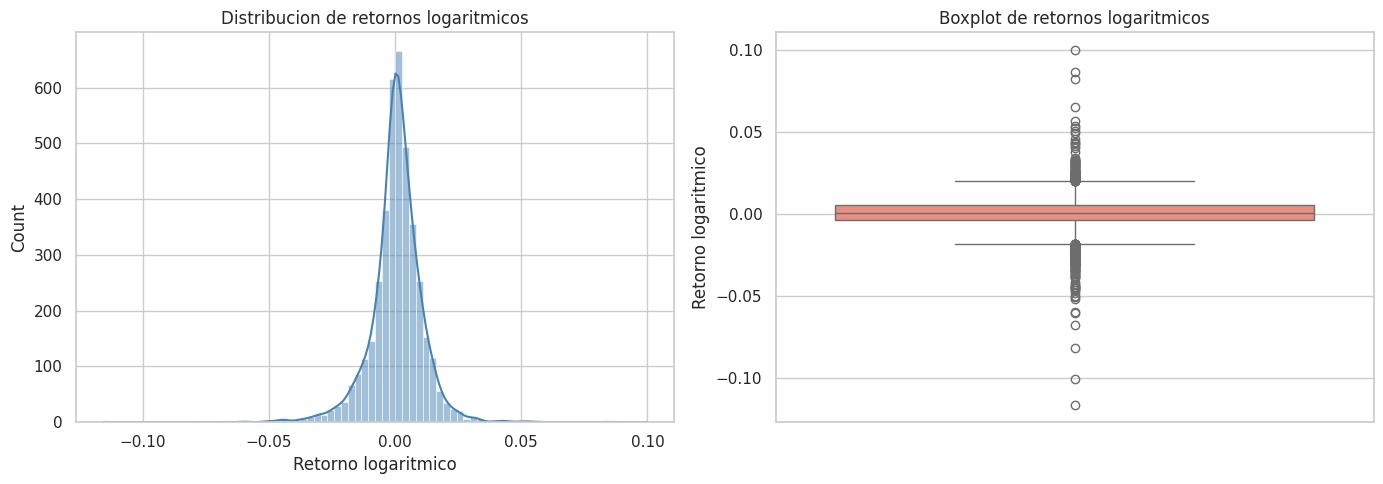

Resumen descriptivo de variables clave:


,count,mean,std,min,25%,50%,75%,max
price_base,"4,023.000000",267.967762,155.480151,77.148857,146.221687,227.698746,386.302002,688.499695
return_simple,"4,022.000000",0.000579,0.010842,-0.109424,-0.003705,0.000707,0.005790,0.105019
return_log,"4,022.000000",0.000519,0.010864,-0.115886,-0.003712,0.000706,0.005773,0.099863
return_abs,"4,022.000000",0.007201,0.008150,0.000000,0.001980,0.004893,0.009703,0.115886
volatility_5d,"4,018.000000",0.008681,0.006833,0.000425,0.004505,0.007098,0.010818,0.089661
volatility_21d,"4,002.000000",0.009280,0.005796,0.002152,0.005839,0.007886,0.011022,0.059006
volatility_63d,"3,960.000000",0.009676,0.005086,0.003237,0.006806,0.008079,0.010993,0.038076


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(spy_feat["return_log"].dropna(), bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribucion de retornos logaritmicos")
axes[0].set_xlabel("Retorno logaritmico")

sns.boxplot(y=spy_feat["return_log"].dropna(), ax=axes[1], color="salmon")
axes[1].set_title("Boxplot de retornos logaritmicos")
axes[1].set_ylabel("Retorno logaritmico")

plt.tight_layout()
plt.show()

print("Resumen descriptivo de variables clave:")
display(
    spy_feat[
        ["price_base", "return_simple", "return_log", "return_abs", "volatility_5d", "volatility_21d", "volatility_63d"]
    ].describe().T
)

In [10]:
autocorr_summary = pd.Series(
    {
        "acf_return_log_lag_1": spy_feat["return_log"].autocorr(lag=1),
        "acf_return_log_lag_5": spy_feat["return_log"].autocorr(lag=5),
        "acf_abs_return_lag_1": spy_feat["return_abs"].autocorr(lag=1),
        "acf_abs_return_lag_5": spy_feat["return_abs"].autocorr(lag=5),
        "acf_volatility_21d_lag_1": spy_feat["volatility_21d"].autocorr(lag=1),
    }
)

print("Autocorrelaciones descriptivas iniciales:")
display(autocorr_summary.to_frame(name="valor"))

Autocorrelaciones descriptivas iniciales:


,valor
acf_return_log_lag_1,-0.102147
acf_return_log_lag_5,-0.000831
acf_abs_return_lag_1,0.312358
acf_abs_return_lag_5,0.292095
acf_volatility_21d_lag_1,0.992341


## 7. Division temporal preliminar

La separacion entre entrenamiento, validacion y prueba debe respetar el orden cronologico. En series temporales no corresponde mezclar fechas al azar porque eso permitiria que informacion futura influya en la etapa de entrenamiento.

En este notebook se propone un corte preliminar:
- `train`: desde el inicio hasta `2020-12-31`.
- `validation`: desde `2021-01-01` hasta `2023-12-31`.
- `test`: desde `2024-01-01` en adelante.

Estos cortes pueden ajustarse mas adelante segun el tipo de modelo y la estrategia de evaluacion.

In [11]:
def dividir_temporalmente(df: pd.DataFrame, train_end: str, valid_end: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Divide el dataset respetando el orden temporal."""
    train = df.loc[:train_end].copy()
    valid = df.loc[pd.Timestamp(train_end) + pd.Timedelta(days=1):valid_end].copy()
    test = df.loc[pd.Timestamp(valid_end) + pd.Timedelta(days=1):].copy()
    return train, valid, test


spy_model = spy_feat.dropna().copy()
train_df, valid_df, test_df = dividir_temporalmente(spy_model, TRAIN_END, VALID_END)

split_summary = pd.DataFrame(
    {
        "subset": ["train", "validation", "test"],
        "filas": [len(train_df), len(valid_df), len(test_df)],
        "fecha_inicio": [train_df.index.min(), valid_df.index.min(), test_df.index.min()],
        "fecha_fin": [train_df.index.max(), valid_df.index.max(), test_df.index.max()],
    }
)

display(split_summary)

,subset,filas,fecha_inicio,fecha_fin
0,train,2706,2010-04-06,2020-12-31
1,validation,753,2021-01-04,2023-12-29
2,test,501,2024-01-02,2025-12-30


## 8. Guardado del dataset limpio

Se exportan tanto el dataset completo con features como las particiones temporales. Esto permite reutilizar las mismas entradas en notebooks posteriores y evita repetir la descarga y limpieza cada vez.

In [12]:
full_csv_path = PROCESSED_DIR / f"{TICKER.lower()}_features_full.csv"
train_csv_path = PROCESSED_DIR / f"{TICKER.lower()}_train.csv"
valid_csv_path = PROCESSED_DIR / f"{TICKER.lower()}_validation.csv"
test_csv_path = PROCESSED_DIR / f"{TICKER.lower()}_test.csv"

spy_model.to_csv(full_csv_path)
train_df.to_csv(train_csv_path)
valid_df.to_csv(valid_csv_path)
test_df.to_csv(test_csv_path)

print("Archivos generados:")
print(full_csv_path)
print(train_csv_path)
print(valid_csv_path)
print(test_csv_path)

Archivos generados:
/home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal/data/processed/spy_features_full.csv
/home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal/data/processed/spy_train.csv
/home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal/data/processed/spy_validation.csv
/home/seba/Documentos/especializacion IA/series temporales/TP/TP2/AST_TPFinal/data/processed/spy_test.csv


## 9. Conclusiones del analisis exploratorio

A partir de la exploracion descriptiva inicial pueden destacarse algunas conclusiones utiles para las siguientes etapas del trabajo:

- Los retornos diarios presentan una media pequena y cercana a cero, por lo que el problema relevante no parece estar en predecir el nivel medio del retorno sino su variabilidad.
- La distribucion de retornos no luce compatible con normalidad estricta, ya que se observan valores extremos y colas mas pesadas que las esperables bajo una distribucion gaussiana.
- La autocorrelacion lineal de los retornos tiende a ser baja, pero la persistencia en medidas como el retorno absoluto o la volatilidad movil sugiere la presencia de `volatility clustering`.
- El periodo de marzo-abril de 2020 aparece como un regimen de estres especialmente marcado, con fuertes movimientos diarios y picos de volatilidad, lo que refuerza la conveniencia de usar modelos capaces de capturar cambios de regimen o heterocedasticidad.
- La muestra incluye fases de relativa calma y episodios de tension, lo que vuelve al dataset util para comparar modelos en contextos de mercado heterogeneos.

En conjunto, estos hallazgos respaldan la idea de modelar la volatilidad como un proceso con persistencia temporal y comportamiento no constante, mas que asumir una varianza estable a lo largo de todo el periodo.

## 10. Cierre

Este notebook deja preparada una base diaria del `SPY` con retornos, volatilidad movil y separacion temporal consistente. La salida sirve como insumo para una etapa posterior de modelado, donde podran evaluarse tecnicas como ARIMA, GARCH, Prophet o redes neuronales recurrentes, siempre manteniendo una logica de entrenamiento con pasado y evaluacion sobre futuro.